In [1]:
from collections import OrderedDict # for vocab

seed = 0

import random
random.seed(seed)

import numpy as np
np.random.seed(seed)

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import seaborn as sns


import utils

utils.add_projects_to_path()

In [2]:
import protein_utils.sequences.encoding as encoding
import protein_utils.sequences.mutations as mutations

from protein_utils.energy.potts import EnergyFunctionCalculator, energy_calc_single_mutants

enc = encoding.DEFAULT_NO_GAP_ENCODER

In [3]:
wt = utils.get_parent_seq(parent="WT")[1:] # drop Met start
wt_np = enc.string_to_np(wt)

In [4]:
L = len(wt) # length of protein
q = 20 # alphabet size

In [5]:
L

272

In [6]:
def generate_synthetic_msa(N, num_muts, poisson=False, poisson_offset = 0, wt_np=wt_np):
    L = len(wt_np)
    num_muts_arr = None
    if poisson:
        num_muts_arr = np.random.poisson(lam=num_muts, size=N) + poisson_offset      
    else:
        num_muts_arr = np.repeat(num_muts, N)
    ret_seq_idx, pos_idx = mutations.get_random_pos_to_mutate(
            seq_idx=np.arange(N),
            num_muts=num_muts_arr,
            L=L )
    msa = np.tile(wt_np, (N, 1))
    mutations.make_random_mutations(msa, ret_seq_idx, pos_idx, mutate_arr=enc.int_mutate_arr)
    return msa


In [7]:
# checks on generate_synthetic_msa
msa = generate_synthetic_msa(1000, 1)
msa2 = generate_synthetic_msa(1000, 2)

# check msa shape
assert(msa.shape == (1000, 272))
# check that they are all single mutants
assert(((msa != wt_np).sum(axis=1) == 1).all())

In [8]:
synthetic_weights = np.random.rand(L, q)
synthetic_weights[np.arange(L), wt_np] += np.random.rand(L)* 2

In [9]:
ec = EnergyFunctionCalculator(h_i_a=synthetic_weights, e_i_a_j_b=np.zeros((L,q, L, q)))

In [10]:
wt_energy = ec(wt_np)
single_muts_energy = ec(msa)
double_muts_energy = ec(msa2)

wt_energy

array(-409.11185087)

In [11]:
bin_labels = ["H", "P", "L", "N"]
single_cut, bins = pd.qcut(single_muts_energy, q=[0, 0.03, 0.17, 0.4, 1.], 
                           retbins=True)
bin_intervals = single_cut.categories.copy()
single_cut = single_cut.rename_categories(bin_labels)
single_cut.value_counts()

H     30
P    140
L    230
N    600
dtype: int64

In [12]:
bins

array([-409.96893179, -409.44798937, -408.89620409, -408.31078009,
       -406.22184044])

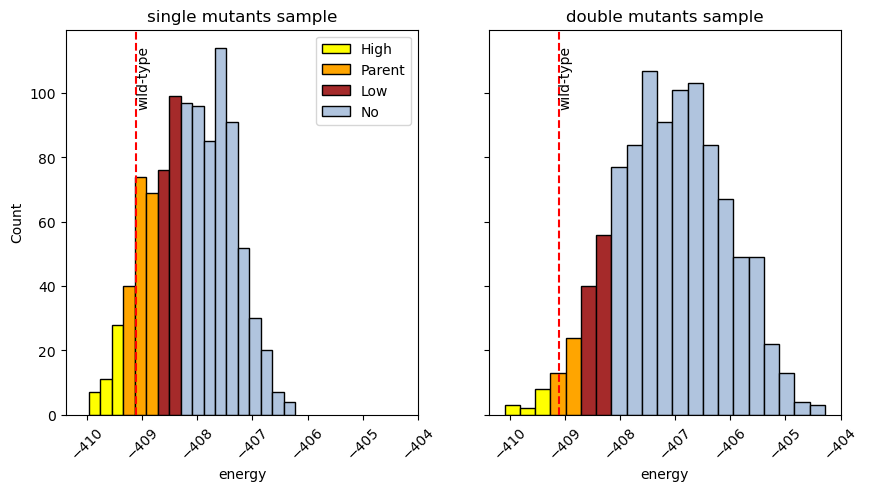

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharex=True, sharey=True)
g = sns.histplot(single_muts_energy,  ax=axes[0])
g = sns.histplot(double_muts_energy, ax=axes[1])


ax=axes[0]
trans = transforms.blended_transform_factory(
    ax.transData, ax.transAxes)
ax.axvline(wt_energy, linestyle="--", color="r")
ax.text(x=wt_energy, y=0.8, s="wild-type", rotation=90, transform=trans)
ax.set_title("single mutants sample")
ax.set_xlabel("energy")
ax.tick_params(axis='x', labelrotation = 45)

for patch in ax.patches:
    color="lightsteelblue"
    p = patch.get_x()
    if p < bins[1]:
        color="yellow"
    elif p < bins[2]:
        color="orange"
    elif p < bins[3]:
        color="brown"
    patch.set_facecolor(color)

    

legend_elements = [Patch(facecolor='yellow', edgecolor='k',
                         label='High'),
                   Patch(facecolor='orange', edgecolor='k',
                         label='Parent'),
                   Patch(facecolor='brown', edgecolor='k',
                         label='Low'),
                   Patch(facecolor='lightsteelblue', edgecolor='k',
                         label='No')
                   
                  ]
ax.legend(handles=legend_elements, loc='upper right')

ax=axes[1]
trans = transforms.blended_transform_factory(
    ax.transData, ax.transAxes)
ax.axvline(wt_energy, linestyle="--", color="r")
ax.text(x=wt_energy, y=0.8, s="wild-type", rotation=90, transform=trans)
ax.set_title("double mutants sample")
ax.set_xlabel("energy")
ax.tick_params(axis='x', labelrotation = 45)

for patch in ax.patches:
    color="lightsteelblue"
    p = patch.get_x()
    if p < bins[1]:
        color="yellow"
    elif p < bins[2]:
        color="orange"
    elif p < bins[3]:
        color="brown"
    patch.set_facecolor(color)

plt.savefig(f"../output/synthetic_histogram.png", dpi=300)

    
pass

In [14]:
ret, energies = energy_calc_single_mutants(wt_np, h_i_a=synthetic_weights, e_i_a_j_b=np.zeros((L,q,L,q)))

In [15]:
mut_df = pd.DataFrame({"idx":ret.i, "mut_aa":ret.a, "energy":energies})

In [16]:
mut_df["pdb_idx"] = mut_df.idx + 1
mut_df["energy_delta"] = mut_df.energy - wt_energy
mut_df["aa"] = mut_df.mut_aa.map(enc.int_to_alpha_dict)
mut_df["wt_aa"] = mut_df.idx.map(wt.__getitem__)

mut_df.to_csv("../output/synthetic_mutation_map.csv", index=False)

In [17]:
mut_df.sort_values("energy", ascending=True).head()

,idx,mut_aa,energy,pdb_idx,energy_delta,aa,wt_aa
704,37,1,-410.075747,38,-0.963896,C,V
711,37,8,-410.071406,38,-0.959555,K,V
715,37,12,-410.035834,38,-0.923984,P,V
709,37,6,-409.986912,38,-0.875061,H,V
718,37,15,-409.982415,38,-0.870564,S,V


In [18]:
mut_df_pivot = mut_df[["pdb_idx", "mut_aa", "energy_delta"]].pivot(
                        index="mut_aa", columns="pdb_idx", values="energy_delta")

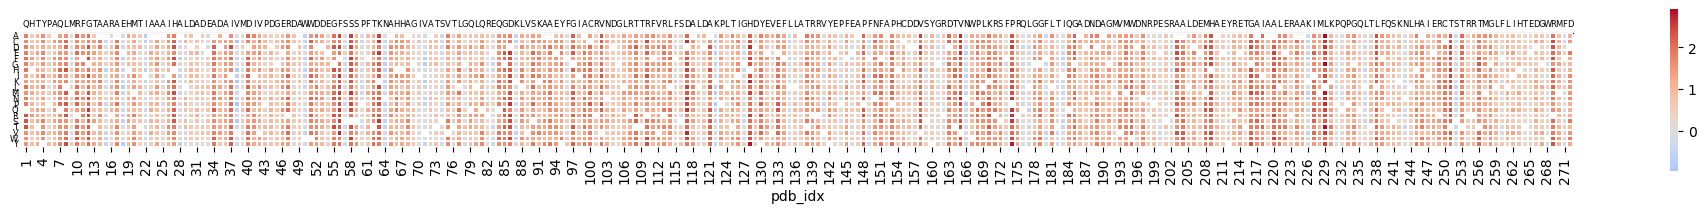

In [19]:
fig = plt.figure(figsize=(25, 3))
sns.heatmap(data=mut_df_pivot, square=True, cbar=True,
            cmap="coolwarm", center=0, linewidths=0.05,
            cbar_kws={"shrink": .70})

ax, cbar_ax = fig.get_axes()
ax.set_ylabel(None)
ax.set_ylabel(None)
ax.set_yticks(ticks=np.arange(q) + .5)
ax.set_yticklabels(labels=list(enc.alphabet), fontsize=6)
ax.yaxis.set_tick_params(length=0)

# label WT on the top
ax_t = ax.secondary_xaxis('top')
ax_t.set_xticks(ticks=np.arange(L) + 0.5)
ax_t.set_xticklabels(labels=list(wt), fontsize=6)
ax_t.xaxis.set_tick_params(length=0)



plt.savefig(f"../output/synthetic_mutation_map.png", dpi=300)


In [20]:
num_test_mutants = 1000
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1)
msa_test

array([[13,  6, 16, ..., 10,  4,  2],
       [13,  6, 16, ..., 10,  4,  2],
       [13,  6, 16, ..., 10,  4,  2],
       ...,
       [13,  6, 16, ..., 10,  4,  2],
       [13,  6, 16, ..., 10,  4,  2],
       [13,  6, 16, ..., 10,  4,  2]], dtype=uint8)

<AxesSubplot: ylabel='Count'>

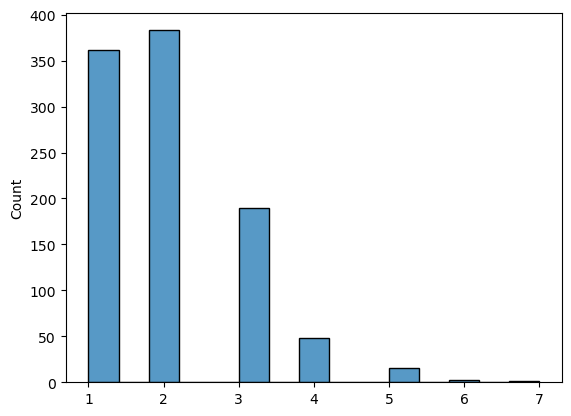

In [21]:
sns.histplot((msa_test != wt_np).sum(axis=1))

In [22]:
test_mutants_energy = ec(msa_test)

In [23]:
test_mutants_energy.min()

-410.2340800429836

In [24]:
test_mutants_energy.max()

-400.6124892834342

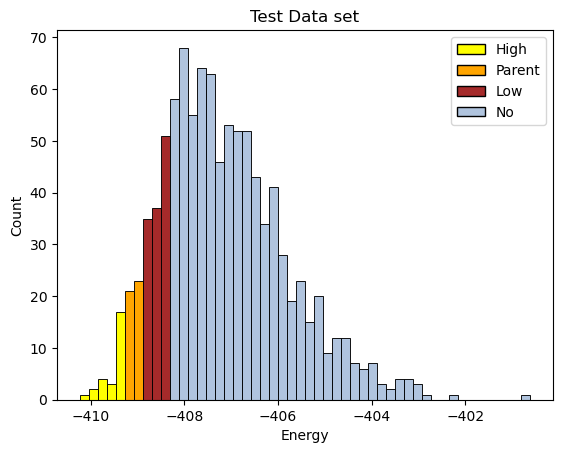

In [25]:
g = sns.histplot(test_mutants_energy, bins=50)
ax = g.axes
for patch in ax.patches:
    color="lightsteelblue"
    p = patch.get_x()
    if p < bins[1]:
        color="yellow"
    elif p < bins[2]:
        color="orange"
    elif p < bins[3]:
        color="brown"
    patch.set_facecolor(color)
    
    
legend_elements = [Patch(facecolor='yellow', edgecolor='k',
                         label='High'),
                   Patch(facecolor='orange', edgecolor='k',
                         label='Parent'),
                   Patch(facecolor='brown', edgecolor='k',
                         label='Low'),
                   Patch(facecolor='lightsteelblue', edgecolor='k',
                         label='No')
                   
                  ]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel("Energy")
ax.set_title("Test Data set")
pass

In [26]:
extend_bins = bins.copy()
extend_bins[0] = -100000
extend_bins[-1] = 1000000
test_mutants_labels = pd.cut(test_mutants_energy, extend_bins, labels=bin_labels)
test_mutants_labels.value_counts()

H     12
P     57
L    125
N    806
dtype: int64

In [27]:
np.save("../output/synthetic/synthetic_weights.npy", synthetic_weights)

In [28]:
np.savez(f"../output/synthetic/msa_round_1_N_{num_test_mutants}.npz", 
         msa=msa_test, labels=test_mutants_labels)

In [29]:
def label_energies(energies, bins=extend_bins, labels=bin_labels):
    return pd.cut(energies, bins, labels=labels)

In [30]:
new_wt = msa_test[test_mutants_labels == "P"][0]

msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1, wt_np=new_wt)

test_mutants_labels = label_energies(ec(msa_test))
np.savez(f"../output/synthetic/msa_round_2_N_{num_test_mutants}.npz",
         msa=msa_test, labels=test_mutants_labels)
test_mutants_labels.value_counts()

H      7
P     47
L    109
N    837
dtype: int64

In [31]:
new_wt = msa_test[test_mutants_labels == "P"][0]

msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1, wt_np=new_wt)

test_mutants_labels = label_energies(ec(msa_test))

np.savez(f"../output/synthetic/msa_round_3_N_{num_test_mutants}.npz",
         msa=msa_test, labels=test_mutants_labels)
test_mutants_labels.value_counts()


H      8
P     49
L    105
N    838
dtype: int64

In [32]:
num_test_mutants = 10000

# round 1
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1)
test_mutants_labels = label_energies(ec(msa_test))
print(test_mutants_labels.value_counts())
np.savez(f"../output/synthetic/msa_round_1_N_{num_test_mutants}.npz", 
         msa=msa_test, labels=test_mutants_labels)

# round 2
new_wt = msa_test[test_mutants_labels == "P"][0]
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1, wt_np=new_wt)

test_mutants_labels = label_energies(ec(msa_test))
np.savez(f"../output/synthetic/msa_round_2_N_{num_test_mutants}.npz",
         msa=msa_test, labels=test_mutants_labels)
print(test_mutants_labels.value_counts())

# round 3
new_wt = msa_test[test_mutants_labels == "P"][0]
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1, wt_np=new_wt)

test_mutants_labels = label_energies(ec(msa_test))
np.savez(f"../output/synthetic/msa_round_3_N_{num_test_mutants}.npz",
         msa=msa_test, labels=test_mutants_labels)
print(test_mutants_labels.value_counts())

H     147
P     585
L    1307
N    7961
dtype: int64
H      87
P     446
L    1121
N    8346
dtype: int64
H     217
P     657
L    1308
N    7818
dtype: int64


In [33]:
num_test_mutants = 100000

# round 1
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1)
test_mutants_labels = label_energies(ec(msa_test))
print(test_mutants_labels.value_counts())
np.savez(f"../output/synthetic/msa_round_1_N_{num_test_mutants}.npz", 
         msa=msa_test, labels=test_mutants_labels)

# round 2
new_wt = msa_test[test_mutants_labels == "P"][0]
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1, wt_np=new_wt)

test_mutants_labels = label_energies(ec(msa_test))
np.savez(f"../output/synthetic/msa_round_2_N_{num_test_mutants}.npz",
         msa=msa_test, labels=test_mutants_labels)
print(test_mutants_labels.value_counts())

# round 3
new_wt = msa_test[test_mutants_labels == "P"][0]
msa_test = generate_synthetic_msa(num_test_mutants, 1, poisson=True, poisson_offset=1, wt_np=new_wt)

test_mutants_labels = label_energies(ec(msa_test))
np.savez(f"../output/synthetic/msa_round_3_N_{num_test_mutants}.npz",
         msa=msa_test, labels=test_mutants_labels)
print(test_mutants_labels.value_counts())

H     1491
P     5652
L    12755
N    80102
dtype: int64
H      705
P     4424
L    10706
N    84165
dtype: int64
H     3403
P     8397
L    15222
N    72978
dtype: int64


In [34]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Training

In [ ]:
import torch
torch.use_deterministic_algorithms(True)
torch.manual_seed(seed)


In [ ]:
seed=100
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-6
NUM_WORKERS = 4

In [ ]:
from coral_pytorch.layers import CoralLayer


# Regular PyTorch Module
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, input_size, hidden_units, num_classes):
        super().__init__()

        # num_classes is used by the CORAL loss function
        self.num_classes = num_classes
        
        # Initialize MLP layers
        all_layers = []
        for hidden_unit in hidden_units:
            layer = torch.nn.Linear(input_size, hidden_unit)
            all_layers.append(layer)
            all_layers.append(torch.nn.ReLU())
            input_size = hidden_unit

        # CORAL: output layer -------------------------------------------
        # Regular classifier would use the following output layer:
        # output_layer = torch.nn.Linear(hidden_units[-1], num_classes)
        
        # We replace it by the CORAL layer:
        output_layer = CoralLayer(size_in=hidden_units[-1],
                                  num_classes=num_classes)
        # ----------------------------------------------------------------
        
        all_layers.append(output_layer)
        self.model = torch.nn.Sequential(*all_layers)
        
    def forward(self, x):
        x = self.model(x)
        return x

In [ ]:
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch
from coral_pytorch.dataset import proba_to_label

import pytorch_lightning as pl
import torchmetrics


# LightningModule that receives a PyTorch model as input
class LightningMLP(pl.LightningModule):
    def __init__(self, model, learning_rate, weight_decay):
        super().__init__()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        # The inherited PyTorch module
        self.model = model

        # Save settings and hyperparameters to the log directory
        # but skip the model parameters
        self.save_hyperparameters(ignore=['model'])

        # Set up attributes for computing the MAE
        self.train_mae = torchmetrics.MeanAbsoluteError()
        self.valid_mae = torchmetrics.MeanAbsoluteError()
        self.test_mae = torchmetrics.MeanAbsoluteError()
        
    # Defining the forward method is only necessary 
    # if you want to use a Trainer's .predict() method (optional)
    def forward(self, x):
        return self.model(x)
        
    # A common forward step to compute the loss and labels
    # this is used for training, validation, and testing below
    def _shared_step(self, batch):
        features, true_labels = batch
        
        # Convert class labels for CORAL ------------------------
        levels = levels_from_labelbatch(
            true_labels, num_classes=self.model.num_classes)
        # -------------------------------------------------------

        logits = self(features)

        # CORAL Loss --------------------------------------------
        # A regular classifier uses:
        # loss = torch.nn.functional.cross_entropy(logits, true_labels)
        loss = coral_loss(logits, levels.type_as(logits))
        # -------------------------------------------------------

        # CORAL Prediction to label -----------------------------
        # A regular classifier uses:
        # predicted_labels = torch.argmax(logits, dim=1)
        probas = torch.sigmoid(logits)
        predicted_labels = proba_to_label(probas)
        # -------------------------------------------------------
        return loss, true_labels, predicted_labels

    def training_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("train_loss", loss)
        self.train_mae(predicted_labels, true_labels)
        self.log("train_mae", self.train_mae, on_epoch=True, on_step=False)
        return loss  # this is passed to the optimzer for training

    def validation_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("valid_loss", loss)
        self.valid_mae(predicted_labels, true_labels)
        self.log("valid_mae", self.valid_mae,
                 on_epoch=True, on_step=False, prog_bar=True)

    def test_step(self, batch, batch_idx):
        _, true_labels, predicted_labels = self._shared_step(batch)
        self.test_mae(predicted_labels, true_labels)
        self.log("test_mae", self.test_mae, on_epoch=True, on_step=False)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [ ]:
from torch.utils.data import Dataset


class MyDataset(Dataset):

    def __init__(self, feature_array, label_array, dtype=np.float32):
        self.features = feature_array.float()
        self.labels = label_array

    def __getitem__(self, index):
        inputs = self.features[index]
        label = self.labels[index]
        return inputs, label

    def __len__(self):
        return self.features.shape[0]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from torch.nn.functional import one_hot

class DataModule(pl.LightningDataModule):
    def __init__(self, syn_data, syn_labels):
        super().__init__()
        self.syn_data = syn_data
        self.syn_labels = syn_labels
        self.label_map = {'H':3, "P":2, "L":1, "N":0}
        
        self.data_features = one_hot(torch.LongTensor(self.syn_data), num_classes=q
                                    ).flatten(start_dim=1, end_dim=-1)
        self.data_labels = torch.LongTensor(self.syn_labels.map(self.label_map.__getitem__))
        
    def prepare_data(self):
        return

    def setup(self, stage=None):
        # Split into
        # 70% train, 10% validation, 20% testing
        
        X_temp, X_test, y_temp, y_test = train_test_split(
            self.data_features,
            self.data_labels,
            test_size=0.2,
            random_state=1,
            stratify=self.data_labels)

        X_train, X_valid, y_train, y_valid = train_test_split(
            X_temp,
            y_temp,
            test_size=0.1,
            random_state=1,
            stratify=y_temp)
        
        self.train = MyDataset(X_train, y_train)
        self.valid = MyDataset(X_valid, y_valid)
        self.test = MyDataset(X_test, y_test)

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS,
                          drop_last=True)

    def val_dataloader(self):
        return DataLoader(self.valid, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS)

In [ ]:
seed=100
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)



In [ ]:
data_module = DataModule(syn_data=msa_test, syn_labels=test_mutants_labels)

In [ ]:
data_module.data_labels.shape

In [ ]:
data_module.data_features.shape

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger


pytorch_model = MultiLayerPerceptron(
    input_size=L*q,
    hidden_units=(500, 50),
    num_classes=4)

lightning_model = LightningMLP(
    model=pytorch_model,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)


callbacks = [ModelCheckpoint(
    save_top_k=1, mode="min", monitor="valid_mae")]  # save top 1 model 
logger = CSVLogger(save_dir="logs/", name="mlp-synthetic-msa")

In [ ]:
import time


trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    callbacks=callbacks,
    #progress_bar_refresh_rate=50,  # recommended for notebooks
    accelerator="auto",  # Uses GPUs or TPUs if available
    devices="auto",  # Uses all available GPUs/TPUs if applicable
    logger=logger,
    deterministic=True,
    log_every_n_steps=10)

start_time = time.time()
trainer.fit(model=lightning_model, datamodule=data_module)

runtime = (time.time() - start_time)/60
print(f"Training took {runtime:.2f} min in total.")

In [ ]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

aggreg_metrics = []
agg_col = "epoch"
for i, dfg in metrics.groupby(agg_col):
    agg = dict(dfg.mean())
    agg[agg_col] = i
    aggreg_metrics.append(agg)

df_metrics = pd.DataFrame(aggreg_metrics)
df_metrics[["train_loss", "valid_loss"]].plot(
    grid=True, legend=True, xlabel='Epoch', ylabel='Loss')
df_metrics[["train_mae", "valid_mae"]].plot(
    grid=True, legend=True, xlabel='Epoch', ylabel='MAE')

In [ ]:
from protein_utils.energy.potts import create_single_mutant

In [ ]:
def get_bin_N_score(i, a):
    x = one_hot(torch.LongTensor(create_single_mutant(i, a, wt_np))).flatten()
    with torch.no_grad():
        logits = pytorch_model(x.float())
        probas = torch.sigmoid(logits) # probability of each class L, P, H
        # find out what is the probability of N and return log of that
        #print(probas)
        return torch.log(1 - probas[0]).item()

In [ ]:
bin_N_score = mut_df.apply(lambda x: get_bin_N_score(x['idx'], x['mut_aa']), axis=1)

In [ ]:
from scipy.stats import spearmanr

In [ ]:
spearmanr(bin_N_score, mut_df.energy)